# Transfer Learning --- ResNet18 (PyTorch)

This notebook completes the transfer-learning requirement of Assignment 4 using
**ResNet18 pre-trained on ImageNet** (the best-performing architecture from the
from-scratch part).

**Pipeline**

This pipeline was achieved after multiple rounds of experimenting with varying regulaization techniques.

1. Load ResNet18 with ImageNet weights from `torchvision`.
2. Replace its 1000-class head with a new `Dropout + Linear(4)` head.
3. **Phase 1** -- freeze the backbone and train only the new head.
4. **Phase 2** -- unfreeze `layer4` and fine-tune at a much smaller LR,
   while keeping every `BatchNorm` layer in `eval()` mode so the ImageNet
   running statistics survive the small 1000-image dataset.

**Regularization applied**

* Dropout (0.3) in the classifier head
* Label smoothing (0.1) in `CrossEntropyLoss`
* `ReduceLROnPlateau` on `val_loss`
* Early stopping with weight restoration
* Two-phase training (frozen head, then fine-tune top of backbone)
* BatchNorm kept in eval mode during fine-tuning

In [1]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Drive (Colab only)
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    pass

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Mounted at /content/drive
Using device: cuda:0


In [2]:
!cp -r /content/drive/MyDrive/dataset /content/local_dataset


In [3]:
# ---- Data loaders -----------------------------------------------------------

data_dir = '/content/local_dataset/'
batch_size = 32

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), train_transforms),
    'valid': datasets.ImageFolder(os.path.join(data_dir, 'valid'), val_test_transforms),
    'test':  datasets.ImageFolder(os.path.join(data_dir, 'test'),  val_test_transforms),
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=batch_size, shuffle=True,  num_workers=2),
    'valid': DataLoader(image_datasets['valid'], batch_size=batch_size, shuffle=False, num_workers=2),
    'test':  DataLoader(image_datasets['test'],  batch_size=batch_size, shuffle=False, num_workers=2),
}

classes = image_datasets['train'].classes
num_classes = len(classes)
print(f"Train: {len(image_datasets['train'])} | Valid: {len(image_datasets['valid'])} | Test: {len(image_datasets['test'])}")
print(f'Classes: {classes}')


Train: 1000 | Valid: 36 | Test: 38
Classes: ['Angry', 'Other', 'Sad', 'happy']


In [4]:
# ---- Build the transfer learning model --------------------------------------
# Load ResNet18 with ImageNet weights and freeze the entire backbone so that
# only the new classifier head is trained in Phase 1.
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

# Replace the original 1000-class fc layer with a small head sized for 4 classes.
# Dropout(0.3) prevents the linear head from memorizing the 1000-image training set.
in_features = model.fc.in_features  # 512 for ResNet18
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters: {trainable:,} / {total:,}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


Trainable parameters: 2,052 / 11,178,564


In [5]:
# ---- Training loop with ReduceLROnPlateau + early stopping ------------------
def train_with_callbacks(model, criterion, optimizer, scheduler,
                         num_epochs=20, patience=10, keep_bn_frozen=False):
    """Train one phase. Tracks the best val_loss, restores those weights on
    early stop, and (optionally) keeps BatchNorm layers in eval mode so the
    pre-trained moving statistics are not corrupted by the small dataset."""
    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs} ' + '-'*15)
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()
                if keep_bn_frozen:
                    for m in model.modules():
                        if isinstance(m, nn.BatchNorm2d):
                            m.eval()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0
            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc  = (running_corrects.double() / len(image_datasets[phase])).item()
            key = 'train' if phase == 'train' else 'val'
            history[f'{key}_loss'].append(epoch_loss)
            history[f'{key}_acc'].append(epoch_acc)
            print(f'{phase.capitalize():5} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

            if phase == 'valid':
                scheduler.step(epoch_loss)
                if epoch_loss < best_val_loss:
                    best_val_loss   = epoch_loss
                    best_weights    = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                    print(f'   -> new best val_loss = {best_val_loss:.4f} (weights saved)')
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f'\nEarly stopping at epoch {epoch+1}; '
                              f'restoring best weights (val_loss = {best_val_loss:.4f}).')
                        model.load_state_dict(best_weights)
                        return model, history

    model.load_state_dict(best_weights)
    print(f'\nFinished phase. Best val_loss = {best_val_loss:.4f}. Best weights restored.')
    return model, history


In [9]:
# ===== Phase 1: train only the new classifier head ===========================
# Label smoothing (epsilon = 0.1) softens the targets and discourages
# over-confident predictions, which is helpful on a small dataset.
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

print('===== Phase 1: training the classifier head (backbone frozen) =====')
model, history_phase1 = train_with_callbacks(
    model, criterion, optimizer, scheduler,
    num_epochs=20, patience=10, keep_bn_frozen=False
)


===== Phase 1: training the classifier head (backbone frozen) =====

Epoch 1/20 ---------------
Train | Loss: 1.0635 | Acc: 0.5990
Valid | Loss: 1.2379 | Acc: 0.5000
   -> new best val_loss = 1.2379 (weights saved)

Epoch 2/20 ---------------
Train | Loss: 0.9462 | Acc: 0.6750
Valid | Loss: 1.2522 | Acc: 0.4722

Epoch 3/20 ---------------
Train | Loss: 0.8384 | Acc: 0.7370
Valid | Loss: 1.3028 | Acc: 0.5278

Epoch 4/20 ---------------
Train | Loss: 0.7906 | Acc: 0.7730
Valid | Loss: 1.3410 | Acc: 0.5278

Epoch 5/20 ---------------
Train | Loss: 0.7339 | Acc: 0.8080
Valid | Loss: 1.4672 | Acc: 0.5000

Epoch 6/20 ---------------
Train | Loss: 0.7150 | Acc: 0.8150
Valid | Loss: 1.4675 | Acc: 0.5278

Epoch 7/20 ---------------
Train | Loss: 0.6950 | Acc: 0.8320
Valid | Loss: 1.4039 | Acc: 0.6111

Epoch 8/20 ---------------
Train | Loss: 0.6596 | Acc: 0.8480
Valid | Loss: 1.4202 | Acc: 0.5833

Epoch 9/20 ---------------
Train | Loss: 0.6346 | Acc: 0.8670
Valid | Loss: 1.4374 | Acc: 0.5833



In [10]:
# ===== Phase 2: fine-tune the top of the backbone ============================
# Unfreeze layer4 (the deepest residual stage) and the new fc head; keep
# the rest of the backbone frozen so the early generic features (edges,
# textures) are preserved. A much smaller learning rate is used so the
# pre-trained features are gently adapted, not overwritten.
#
# BatchNorm layers are kept in eval() mode throughout (keep_bn_frozen=True),
# because unfreezing them with only ~1000 images would corrupt their
# ImageNet running statistics and destabilize training.

for name, param in model.named_parameters():
    param.requires_grad = name.startswith('layer4') or name.startswith('fc')

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-7)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable parameters: {trainable:,}')
print('===== Phase 2: fine-tuning layer4 + fc (BatchNorm kept frozen) =====')
model, history_phase2 = train_with_callbacks(
    model, criterion, optimizer, scheduler,
    num_epochs=15, patience=8, keep_bn_frozen=True
)


Phase 2 trainable parameters: 8,395,780
===== Phase 2: fine-tuning layer4 + fc (BatchNorm kept frozen) =====

Epoch 1/15 ---------------
Train | Loss: 0.9282 | Acc: 0.6820
Valid | Loss: 1.2941 | Acc: 0.5000
   -> new best val_loss = 1.2941 (weights saved)

Epoch 2/15 ---------------
Train | Loss: 0.8881 | Acc: 0.7050
Valid | Loss: 1.3366 | Acc: 0.5000

Epoch 3/15 ---------------
Train | Loss: 0.8857 | Acc: 0.7250
Valid | Loss: 1.2967 | Acc: 0.4722

Epoch 4/15 ---------------
Train | Loss: 0.8660 | Acc: 0.7360
Valid | Loss: 1.2821 | Acc: 0.4722
   -> new best val_loss = 1.2821 (weights saved)

Epoch 5/15 ---------------
Train | Loss: 0.8567 | Acc: 0.7190
Valid | Loss: 1.2728 | Acc: 0.4722
   -> new best val_loss = 1.2728 (weights saved)

Epoch 6/15 ---------------
Train | Loss: 0.8229 | Acc: 0.7500
Valid | Loss: 1.3129 | Acc: 0.4722

Epoch 7/15 ---------------
Train | Loss: 0.7937 | Acc: 0.7840
Valid | Loss: 1.2468 | Acc: 0.4722
   -> new best val_loss = 1.2468 (weights saved)

Epoch 8/

Evaluating on Unseen Test Set

--- Classification Report ---
              precision    recall  f1-score   support

       Angry       0.64      0.70      0.67        10
       Other       0.50      0.17      0.25         6
         Sad       0.47      0.82      0.60        11
       happy       0.67      0.36      0.47        11

    accuracy                           0.55        38
   macro avg       0.57      0.51      0.50        38
weighted avg       0.58      0.55      0.52        38



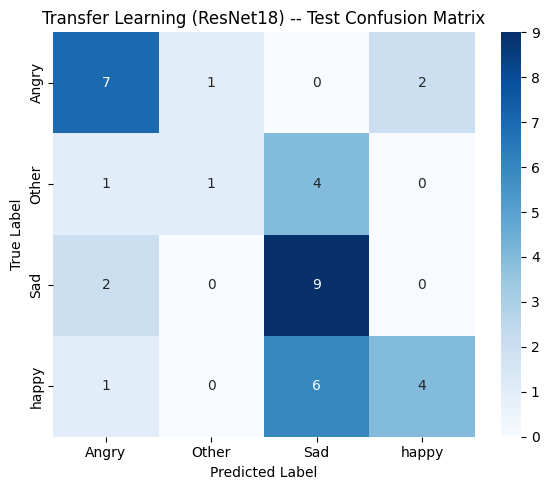

In [11]:
# ---- Final evaluation on the held-out test set ------------------------------
print('=' * 40 + '\nEvaluating on Unseen Test Set\n' + '=' * 40)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('\n--- Classification Report ---')
print(classification_report(all_labels, all_preds, target_names=classes, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Transfer Learning (ResNet18) -- Test Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
